Task 2.1 



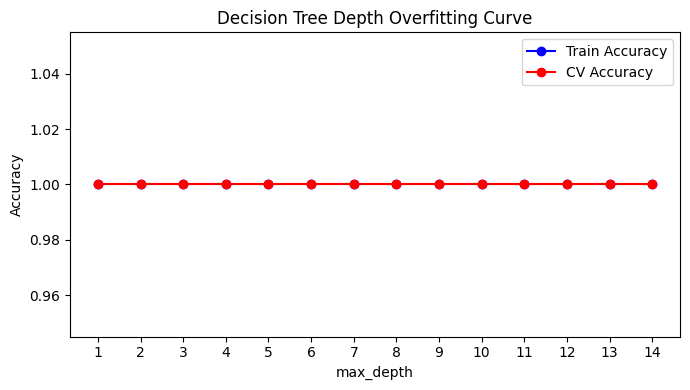

Best max_depth by CV score: 1


In [1]:
print("Task 2.1 \n")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

df = pd.read_csv('students_feature_engineered_v2.csv')
X = df.drop(columns=['Pass'])
y = df['Pass']

depths = list(range(1, 15))
train_accs = []
cv_accs = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X, y)
    train_accs.append(clf.score(X, y))
    
    cv_scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
    cv_accs.append(cv_scores.mean())

plt.figure(figsize=(7, 4))
plt.plot(depths, train_accs, marker='o', label='Train Accuracy', color='blue')
plt.plot(depths, cv_accs, marker='o', label='CV Accuracy', color='red')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Depth Overfitting Curve')
plt.xticks(depths)
plt.legend()
plt.tight_layout()
plt.show()

best_depth_idx = np.argmax(cv_accs)
print(f"Best max_depth by CV score: {depths[best_depth_idx]}")


Task 2.2 



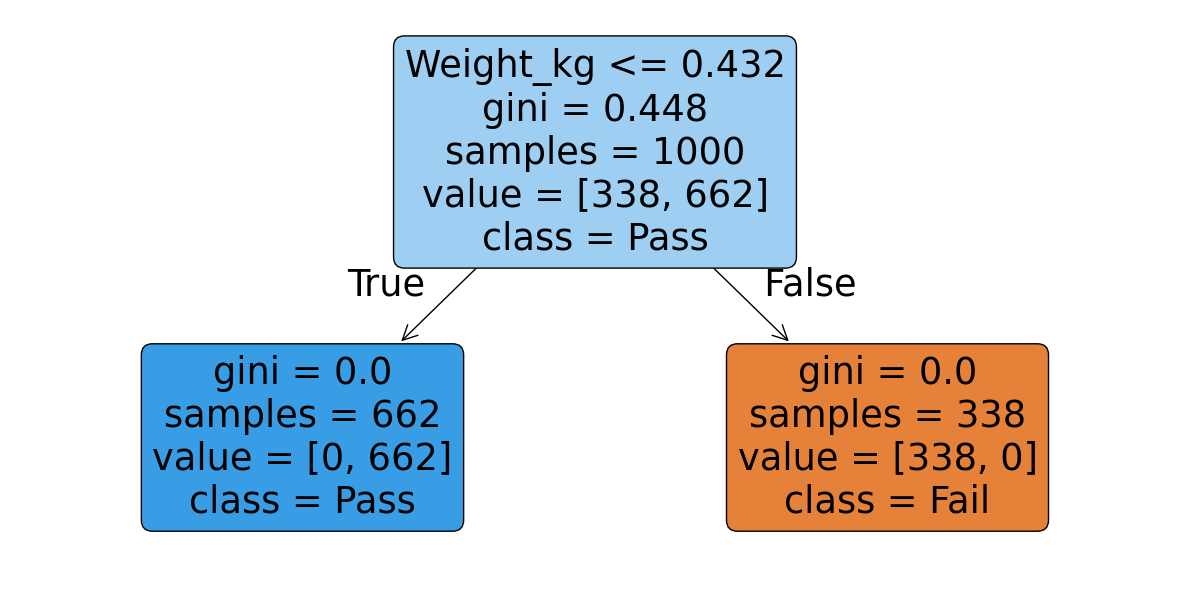

|--- Weight_kg <= 0.43
|   |--- class: 1
|--- Weight_kg >  0.43
|   |--- class: 0



In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

print("\nTask 2.2 \n")
df = pd.read_csv('students_feature_engineered_v2.csv')
X = df.drop(columns=['Pass'])
y = df['Pass']

clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X, y)

fig, ax = plt.subplots(figsize=(12, 6))
plot_tree(clf, feature_names=X.columns.tolist(), class_names=['Fail', 'Pass'], filled=True, rounded=True, ax=ax)
plt.tight_layout()
plt.show()

tree_rules = export_text(clf, feature_names=X.columns.tolist())
print(tree_rules)

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
print("Task 2.3 \n")
df = pd.read_csv('students_feature_engineered_v2.csv')
X = df.drop(columns=['Pass'])
y_reg = df['Weight_kg'] 

Xr_train, Xr_test, yr_train, yr_test = train_test_split(X, y_reg, test_size=0.20, random_state=42)

depths = [2, 4, 8]
print("Depth, Test MAE, Test RMSE")
for d in depths:
    reg = DecisionTreeRegressor(max_depth=d, random_state=42)
    reg.fit(Xr_train, yr_train)
    preds = reg.predict(Xr_test)
    mae = mean_absolute_error(yr_test, preds)
    rmse = root_mean_squared_error(yr_test, preds)
    print(f"{d:5d}, {mae:8.3f}, {rmse:9.3f}")

Task 2.3 

Depth, Test MAE, Test RMSE
    2,    0.146,     0.186
    4,    0.000,     0.000
    8,    0.000,     0.000


Task 2.4 



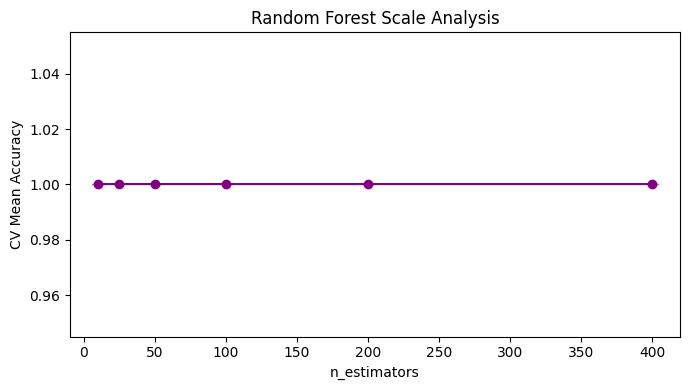

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
print("Task 2.4 \n")
df = pd.read_csv('students_feature_engineered_v2.csv')
X = df.drop(columns=['Pass'])
y = df['Pass']

estimators = [10, 25, 50, 100, 200, 400]
means = []
stds = []

for n in estimators:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
    means.append(scores.mean())
    stds.append(scores.std())

plt.figure(figsize=(7, 4))
plt.errorbar(estimators, means, yerr=stds, fmt='-o', color='purple', ecolor='gray', capsize=4)
plt.xlabel('n_estimators')
plt.ylabel('CV Mean Accuracy')
plt.title('Random Forest Scale Analysis')
plt.tight_layout()
plt.show()

Task 2.5 



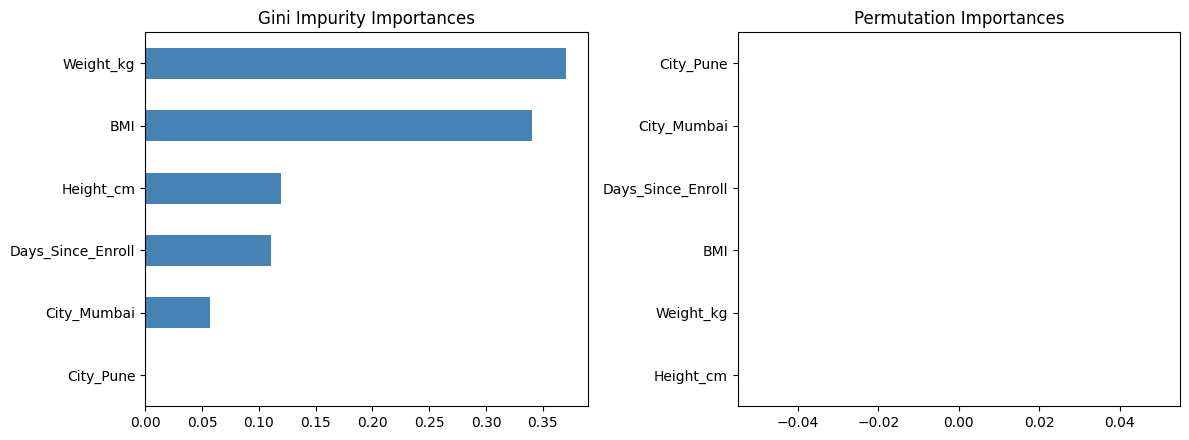

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

print("Task 2.5 \n")
df = pd.read_csv('students_feature_engineered_v2.csv')
X = df.drop(columns=['Pass'])
y = df['Pass']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=200, random_state=42).fit(X_train, y_train)

impurity_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

perm_res = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42)
permutation_imp = pd.Series(perm_res.importances_mean, index=X.columns).sort_values()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
impurity_imp.plot(kind='barh', ax=ax1, color='steelblue', title='Gini Impurity Importances')
permutation_imp.plot(kind='barh', ax=ax2, color='seagreen', title='Permutation Importances')
plt.tight_layout()
plt.show()

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
print("Task 2.6 \n")
df = pd.read_csv('students_feature_engineered_v2.csv')
X = df.drop(columns=['Pass'])
y = df['Pass']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

param_grid = {
    'clf__n_neighbors': [3, 5, 7, 9, 11],
    'clf__weights': ['uniform', 'distance'],
    'clf__metric': ['euclidean', 'manhattan']
}

scaled_pipe = Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier())])
grid_scaled = GridSearchCV(scaled_pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1).fit(X_train, y_train)

unscaled_pipe = Pipeline([('clf', KNeighborsClassifier())]) 
grid_unscaled = GridSearchCV(unscaled_pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1).fit(X_train, y_train)

print(f"Scaled Pipeline Best CV Score  : {grid_scaled.best_score_:.3f} using {grid_scaled.best_params_}")
print(f"Unscaled Pipeline Best CV Score: {grid_unscaled.best_score_:.3f} using {grid_unscaled.best_params_}")

Task 2.6 

Scaled Pipeline Best CV Score  : 1.000 using {'clf__metric': 'euclidean', 'clf__n_neighbors': 3, 'clf__weights': 'uniform'}
Unscaled Pipeline Best CV Score: 1.000 using {'clf__metric': 'euclidean', 'clf__n_neighbors': 3, 'clf__weights': 'uniform'}


Mini project

Decision Tree   Best CV Accuracy: 1.000
Random Forest   Best CV Accuracy: 1.000
KNN             Best CV Accuracy: 1.000

Selected Model Winner: Decision Tree

              precision    recall  f1-score   support

        Fail       1.00      1.00      1.00        68
        Pass       1.00      1.00      1.00       132

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



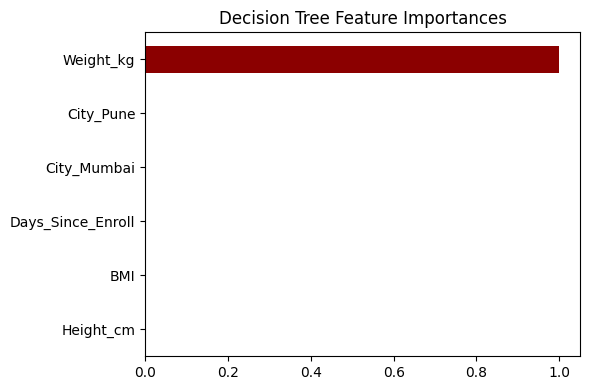

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

print("Mini project\n")
df = pd.read_csv('students_feature_engineered_v2.csv')
X = df.drop(columns=['Pass'])
y = df['Pass']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

candidates = [
    ('Decision Tree', 
     Pipeline([('s', StandardScaler()), ('clf', DecisionTreeClassifier(random_state=42))]),
     {'clf__max_depth': [2, 3, 4, 5], 'clf__min_samples_split': [2, 5, 10], 'clf__criterion': ['gini', 'entropy']}),
    
    ('Random Forest', 
     Pipeline([('s', StandardScaler()), ('clf', RandomForestClassifier(random_state=42))]),
     {'clf__n_estimators': [50, 100, 200], 'clf__max_depth': [3, 5, None], 'clf__max_features': ['sqrt', 'log2']}),
    
    ('KNN', 
     Pipeline([('s', StandardScaler()), ('clf', KNeighborsClassifier())]),
     {'clf__n_neighbors': [3, 5, 7, 9, 11], 'clf__weights': ['uniform', 'distance'], 'clf__metric': ['euclidean', 'manhattan']})
]

best_cv_score = 0
winner_name = ""
winner_pipeline = None

for name, pipe, grid in candidates:
    search = GridSearchCV(pipe, grid, cv=5, scoring='accuracy', n_jobs=-1).fit(X_train, y_train)
    print(f"{name:15s} Best CV Accuracy: {search.best_score_:.3f}")
    if search.best_score_ > best_cv_score:
        best_cv_score = search.best_score_
        winner_name = name
        winner_pipeline = search.best_estimator_

print(f"\nSelected Model Winner: {winner_name}\n")

test_predictions = winner_pipeline.predict(X_test)
print(classification_report(y_test, test_predictions, target_names=['Fail', 'Pass']))

if winner_name in ['Decision Tree', 'Random Forest']:
    importances = pd.Series(winner_pipeline.named_steps['clf'].feature_importances_, index=X.columns).sort_values()
    plt.figure(figsize=(6, 4))
    importances.plot(kind='barh', color='darkred')
    plt.title(f'{winner_name} Feature Importances')
    plt.tight_layout()
    plt.show()
else:
    print("Feature importance scores are unavailable because the winning model is KNN.")

In [9]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv('students_feature_engineered_v2.csv')
X = df.drop(columns=['Pass'])
y = df['Pass']

rf_oob = RandomForestClassifier(n_estimators=200, oob_score=True, random_state=42)
rf_oob.fit(X, y)

print(f"Model Out-Of-Bag (OOB) Accuracy Score: {rf_oob.oob_score_:.3f}")

Model Out-Of-Bag (OOB) Accuracy Score: 1.000
